### 8.Cobweb

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def fn_logistica(x, a):
    return a * x * (1 - x)

In [3]:
def iterar(f, x0, N, **kwargs):
    xs = np.zeros(N + 1)
    xs[0] = x0
    for n in range(N):
        xs[n + 1] = f(xs[n], **kwargs)
    return xs

In [4]:
def cobweb_segmentos(orbita):
    N = len(orbita) - 1
    xs_plot = np.zeros(2 * N + 1)
    ys_plot = np.zeros(2 * N + 1)

    # punto de arranque: (x0, 0)
    xs_plot[0] = orbita[0]
    ys_plot[0] = 0.0

    for n in range(N):
        # segmento vertical
        xs_plot[2 * n + 1] = orbita[n]
        ys_plot[2 * n + 1] = orbita[n + 1]
        # segmento horizontal
        xs_plot[2 * n + 2] = orbita[n + 1]
        ys_plot[2 * n + 2] = orbita[n + 1]

    return xs_plot, ys_plot

In [8]:
def plot_cobweb(a, x0, N, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    xx = np.linspace(0, 1, 400)
    ax.plot(xx, fn_logistica(xx, a), 'b-', lw=1.5, label=f'f(x) = {a}·x(1-x)')

    ax.plot(xx, xx, 'k--', lw=1, label='y = x')

    orb = iterar(fn_logistica, x0, N, a=a)
    xs_p, ys_p = cobweb_segmentos(orb)
    ax.plot(xs_p, ys_p, 'r-', lw=0.8, alpha=0.8)

    ax.plot(x0, 0, 'go', ms=6, label=f'x0 = {x0}')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('x_n')
    ax.set_ylabel('x_{n+1}')
    ax.set_title(f'Cobweb  |  a = {a},  x0 = {x0},  N = {N}')
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=8)
    return ax

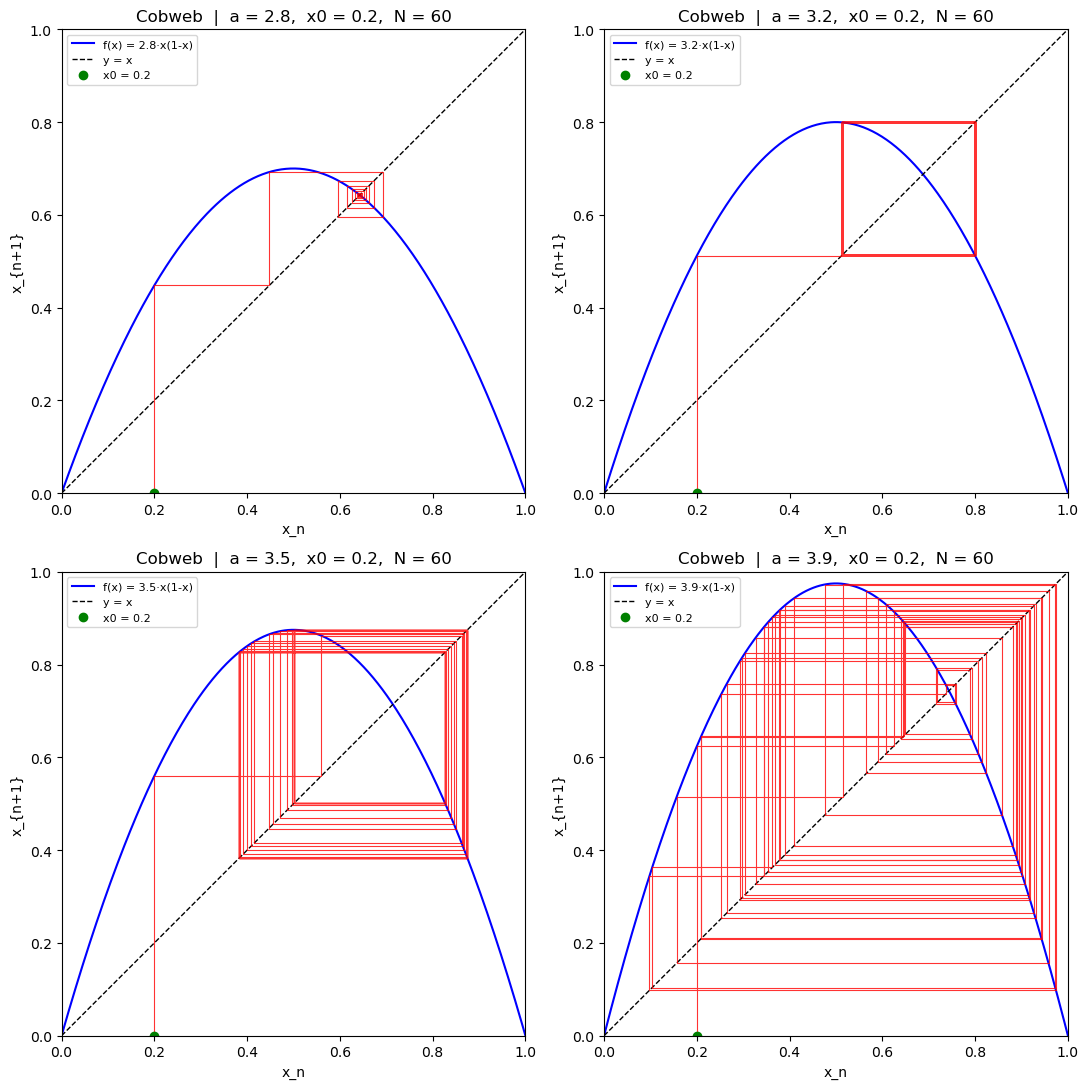

In [6]:
valores_a = [2.8, 3.2, 3.5, 3.9]
x0 = 0.2
N = 60

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, a in zip(axes.flat, valores_a):
    plot_cobweb(a, x0, N, ax=ax)
plt.tight_layout()
plt.show()

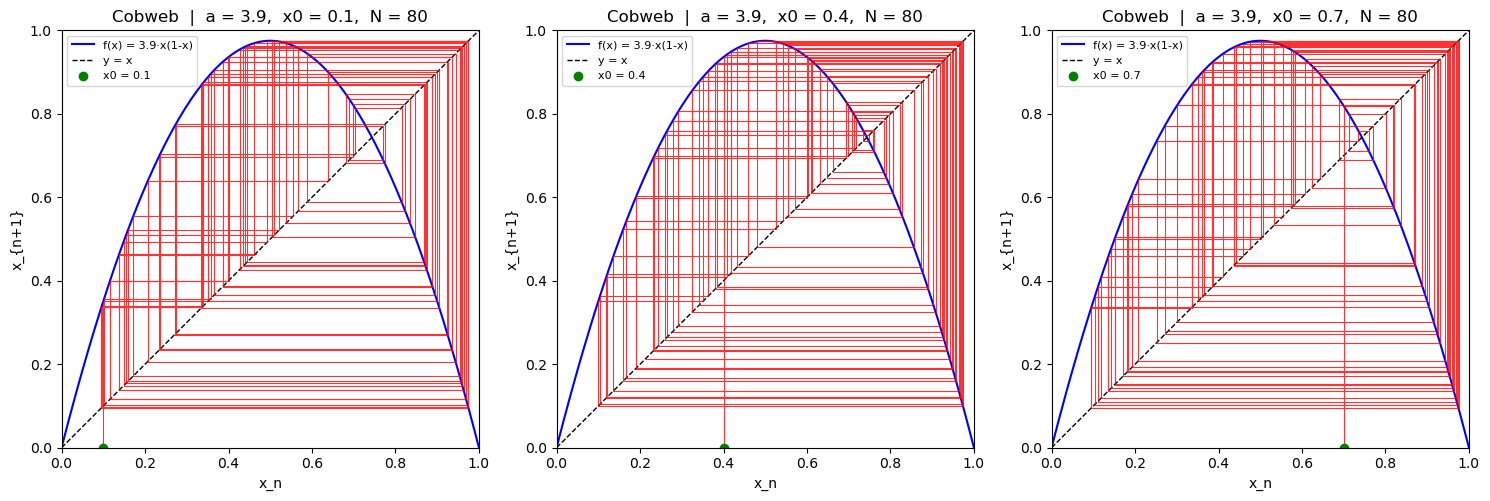

In [9]:
a_fijo = 3.9   # caos
x0_lista = [0.1, 0.4, 0.7]
N = 80

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, x0 in zip(axes, x0_lista):
    plot_cobweb(a_fijo, x0, N, ax=ax)
plt.tight_layout()
plt.show()